# Two-Tower Neural Retrieval: Managed Training and Evaluation

This notebook is the public analytical layer for the objective-conditioned two-tower retriever. Production training and evaluation logic lives in typed modules and CLI workflows. The notebook reads compact committed evidence so GitHub viewers can audit the experiment without AWS access.

In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "reports" / "metrics" / "two_tower_resume_proof.json").is_file()
)
resume_path = ROOT / 'reports/metrics/two_tower_resume_proof.json'
fold_path = ROOT / 'reports/metrics/two_tower_fold0_training.json'

resume = json.loads(resume_path.read_text(encoding='utf-8'))
fold = json.loads(fold_path.read_text(encoding='utf-8')) if fold_path.exists() else None
print(f"resume_proof={resume['status']} commit={resume['code_commit'][:7]}")
print(f"fold0_training={'available' if fold is not None else 'pending'}")

resume_proof=passed commit=a775bb7
fold0_training=available


## Proven cross-worker durability

In [2]:
proof_rows = [
    ('Durable checkpoint objects', resume['checkpoint_objects']),
    ('Checkpoint bytes', f"{resume['checkpoint_bytes']:,}"),
    ('Resumed from step', resume['resumed_from_step']),
    ('Final step', resume['final_step']),
    ('Advanced steps', resume['advanced_steps']),
    ('Pipeline elapsed seconds', resume['pipeline_elapsed_seconds']),
]
pd.DataFrame(proof_rows, columns=['Invariant', 'Measured result'])

Out[2]: 
                    Invariant Measured result
0  Durable checkpoint objects               7
1            Checkpoint bytes   2,848,858,963
2           Resumed from step              40
3                  Final step              80
4              Advanced steps              40
5    Pipeline elapsed seconds         817.041


The resume proof uses a fresh managed worker for the continuation stage. The final global step must strictly exceed the restored step; checkpoint presence alone is not counted as a pass.

## Fold 0 experimental contract

In [3]:
contract = pd.DataFrame([
    ('Held-out fold', 0),
    ('Training folds', '1, 2, 3, 4'),
    ('Candidate depths', '20 / 50 / 100 / 200 / 400 / 800'),
    ('Primary evidence', 'incremental Recall@20 ceiling vs frozen base retrieval'),
    ('Complementarity evidence', 'neural-only positive hits by objective'),
    ('Uncertainty', 'paired session-level percentile bootstrap'),
    ('Scaling rule', 'do not run folds 1–4 unless Fold 0 adds held-out value'),
], columns=['Contract', 'Value'])
contract


Out[3]: 
                   Contract                                              Value
0             Held-out fold                                                  0
1            Training folds                                         1, 2, 3, 4
2          Candidate depths                    20 / 50 / 100 / 200 / 400 / 800
3          Primary evidence  incremental Recall@20 ceiling vs frozen base r...
4  Complementarity evidence             neural-only positive hits by objective
5               Uncertainty          paired session-level percentile bootstrap
6              Scaling rule  do not run folds 1–4 unless Fold 0 adds held-o...


## Fold 0 training result

In [4]:
if fold is None:
    print('Fold 0 full training has not been published yet. Run the managed fold workflow, then rerun this notebook.')
else:
    display(pd.DataFrame([
        ('status', fold['status']),
        ('global_step', fold['global_step']),
        ('completed_epochs', fold['completed_epochs']),
        ('best_valid_loss', fold['best_valid_loss']),
        ('billable_seconds', fold['billable_seconds']),
        ('checkpoint_bytes', fold['checkpoint_bytes']),
    ], columns=['Metric', 'Value']))


,Metric,Value
0,status,passed
1,global_step,9600
2,completed_epochs,4
3,best_valid_loss,4.544512
4,billable_seconds,621
5,checkpoint_bytes,3798484235


## Learning dynamics
The managed run completed four epochs and 9,600 optimizer steps. The minimum validation loss occurred at epoch 1; the evaluator uses that saved best checkpoint. Loss and MRR below are diagnostics against sampled negatives. They do not measure full-catalogue Recall@20.


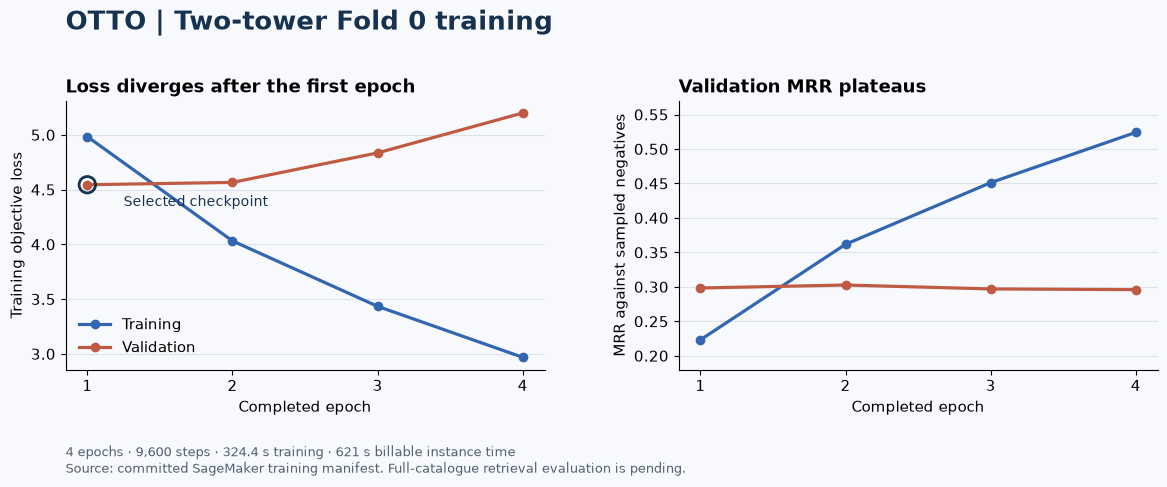

In [5]:
import matplotlib.pyplot as plt
import numpy as np

history = fold['history']
epochs = np.array([row['epoch'] + 1 for row in history])
train_loss = np.array([row['train']['loss'] for row in history])
valid_loss = np.array([row['valid']['loss'] for row in history])
best = int(np.argmin(valid_loss))
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), facecolor='#f7f9fc')
for ax in axes:
    ax.set_facecolor('#f7f9fc')
    ax.set_xticks(epochs)
    ax.set_xlabel('Completed epoch')
    ax.grid(axis='y', color='#dce3ec', linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].plot(epochs, train_loss, 'o-', color='#3366b0', lw=2.3, label='Training')
axes[0].plot(epochs, valid_loss, 'o-', color='#c05b43', lw=2.3, label='Validation')
axes[0].scatter(epochs[best], valid_loss[best], s=140, facecolors='none',
                edgecolors='#17324f', linewidths=2, zorder=5)
axes[0].annotate('Selected checkpoint', xy=(epochs[best], valid_loss[best]),
                 xytext=(1.25, 4.35), color='#17324f', fontsize=10)
axes[0].set_title('Loss diverges after the first epoch', loc='left', fontweight='bold')
axes[0].set_ylabel('Training objective loss')
axes[0].legend(frameon=False)
axes[1].plot(epochs, [row['train']['mrr'] for row in history], 'o-', color='#3366b0', lw=2.3)
axes[1].plot(epochs, [row['valid']['mrr'] for row in history], 'o-', color='#c05b43', lw=2.3)
axes[1].set_title('Validation MRR plateaus', loc='left', fontweight='bold')
axes[1].set_ylabel('MRR against sampled negatives')
axes[1].set_ylim(0.18, 0.57)
fig.suptitle('OTTO | Two-tower Fold 0 training', x=0.07, ha='left',
             fontsize=19, fontweight='bold', color='#17324f')
fig.text(0.07, 0.015, '4 epochs · 9,600 steps · 324.4 s training · 621 s billable instance time\n'
         'Source: committed SageMaker training manifest. Full-catalogue retrieval evaluation is pending.',
         fontsize=9, color='#536174')
fig.subplots_adjust(left=0.07, right=0.98, top=0.79, bottom=0.23, wspace=0.28)
figure_path = ROOT / 'reports/figures/two_tower_learning_curves.png'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=180, facecolor=fig.get_facecolor())
plt.show()


Validation loss rises while training loss falls, consistent with overfitting on this split. Fold 0 participates in checkpoint selection; its later retrieval comparison is exploratory validation. The next decision depends on additional positive items recovered beyond the frozen base pool, with paired session bootstrap intervals. An untouched evaluation remains necessary for a generalization claim.


## Decision gate

The neural retriever advances to five-fold OOF only if its held-out candidates recover positives that the frozen revisit/co-visitation/Item2Vec system misses. Architecture complexity is not treated as evidence of quality.